# Neuralk NICLClassifier: Explainability

This notebook demonstrates how to interpret and explain predictions made by Neuralk's **In-Context Learning (NICL)** classifier. We explore feature importances, prediction confidence, and model transparency tools to help you understand *why* the model makes its decisions.

---

## Getting Access

To use the Neuralk Cloud API, you need an API key. Run the following command to get started:

```bash
neuralk login
```

This will display instructions and a link to create your account at: https://prediction.neuralk-ai.com/register

Your API key will be generated upon registration. It looks like `nk_live_xxxxxxxxxxxx`.

## Setting up your API key

You can provide your API key in two ways:

**Option 1: Environment variable (recommended)**

```bash
# Linux/macOS
export NEURALK_API_KEY=nk_live_your_api_key_here

# Windows
set NEURALK_API_KEY=nk_live_your_api_key_here
```

**Option 2: Pass directly to the classifier**

```python
from neuralk import NICLClassifier
clf = NICLClassifier(api_key="nk_live_your_api_key_here")
```

## Setup


In [16]:
%%capture
%pip install -q neuralk scikit-learn skrub

In [1]:
import os
import warnings

import numpy as np
import skrub
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline

from neuralk import NICLClassifier, datasets

skrub.set_config(use_table_report=False)
warnings.filterwarnings("ignore", message="Found unknown categories.*during transform")


API_KEY = "nk_live_your_api_key_here"
os.environ["NEURALK_API_KEY"] = API_KEY

---

## 1. Load and Prepare the Housing Dataset

In [2]:
X, y = datasets.housing()

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

print(f"Train: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Test:  {X_test.shape[0]} samples")
print(f"Classes: {np.unique(y).shape[0]}")
X_train.head()

Train: 2197 samples, 80 features
Test:  733 samples
Classes: 5


/Users/tma/workspaces/.venv/lib/python3.14/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


,MS_SubClass,MS_Zoning,Lot_Frontage,Lot_Area,Street,Alley,Lot_Shape,Land_Contour,Utilities,Lot_Config,...,Pool_QC,Fence,Misc_Feature,Misc_Val,Mo_Sold,Year_Sold,Sale_Type,Sale_Condition,Longitude,Latitude
844,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,68,9017,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Inside,...,No_Pool,No_Fence,None,0,9,2009,WD,Normal,-93.691667,42.016903
2730,One_and_Half_Story_PUD_All_Ages,Residential_Low_Density,0,1700,Pave,No_Alley_Access,Regular,HLS,AllPub,Inside,...,No_Pool,No_Fence,None,0,4,2006,WD,Normal,-93.674402,42.023651
2793,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,0,14781,Pave,No_Alley_Access,Moderately_Irregular,Lvl,AllPub,CulDSac,...,No_Pool,No_Fence,None,0,8,2006,WD,Normal,-93.685697,42.018188
1187,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,85,11050,Pave,No_Alley_Access,Regular,Lvl,AllPub,Inside,...,No_Pool,Good_Wood,None,0,10,2008,WD,Family,-93.634976,42.049141
2770,Two_Story_1946_and_Newer,Residential_Low_Density,65,12438,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Inside,...,No_Pool,No_Fence,None,0,8,2006,WD,Normal,-93.688302,42.021209


---

## 2. Train the NICLClassifier

In [3]:
pipeline = make_pipeline(
    skrub.TableVectorizer(),
    skrub.SquashingScaler(),
    SimpleImputer(),
    NICLClassifier(api_key=API_KEY),
)

pipeline.fit(X_train, y_train)

predictions = pipeline.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 77.35%


---

## 3. Prediction Probabilities

The `NICLClassifier` supports `predict_proba()`, which returns the model's confidence for each class. This is a first step toward explainability: understanding *how certain* the model is about its predictions.

In [4]:
probabilities = pipeline.predict_proba(X_test)

print(f"Shape: {probabilities.shape}  (samples x classes)")
print(f"\nPrediction probabilities for the first 5 test samples:")
for i in range(5):
    probs = probabilities[i]
    pred = predictions[i]
    true = y_test[i]
    confidence = probs.max()
    print(f"  Sample {i}: predicted={pred}, true={true}, confidence={confidence:.2%}, probs={np.round(probs, 3)}")

Shape: (733, 5)  (samples x classes)

Prediction probabilities for the first 5 test samples:
  Sample 0: predicted=2, true=2, confidence=60.23%, probs=[0.017 0.253 0.602 0.123 0.004]
  Sample 1: predicted=0, true=0, confidence=97.03%, probs=[0.97 0.03 0.   0.   0.  ]
  Sample 2: predicted=3, true=3, confidence=83.87%, probs=[0.    0.    0.133 0.839 0.029]
  Sample 3: predicted=1, true=0, confidence=55.92%, probs=[0.42  0.559 0.021 0.    0.   ]
  Sample 4: predicted=0, true=1, confidence=91.58%, probs=[0.916 0.084 0.001 0.    0.   ]


---

## 4. Confidence Distribution

Visualizing the distribution of prediction confidence helps identify where the model is uncertain. Low-confidence predictions are good candidates for human review.

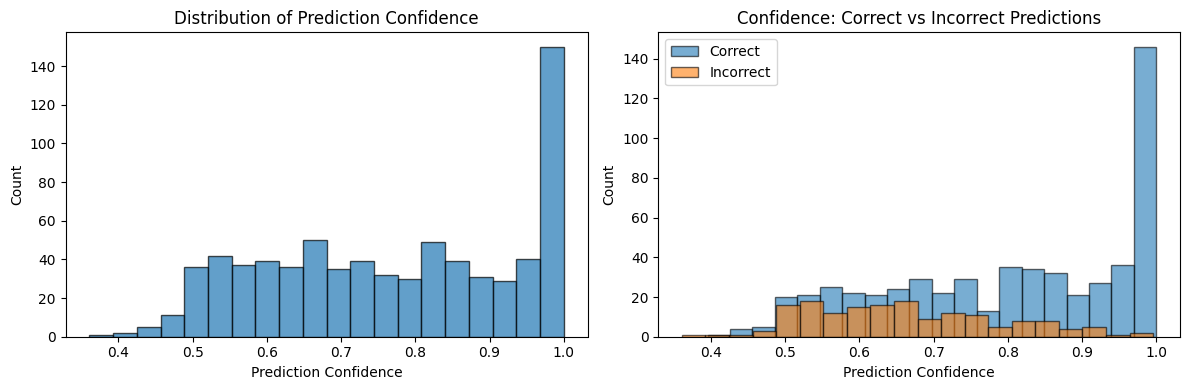

In [5]:
import matplotlib.pyplot as plt

max_confidence = probabilities.max(axis=1)
correct = predictions == y_test

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confidence histogram
axes[0].hist(max_confidence, bins=20, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Prediction Confidence")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Prediction Confidence")

# Confidence vs correctness
axes[1].hist(max_confidence[correct], bins=20, alpha=0.6, label="Correct", edgecolor="black")
axes[1].hist(max_confidence[~correct], bins=20, alpha=0.6, label="Incorrect", edgecolor="black")
axes[1].set_xlabel("Prediction Confidence")
axes[1].set_ylabel("Count")
axes[1].set_title("Confidence: Correct vs Incorrect Predictions")
axes[1].legend()

plt.tight_layout()
plt.show()

---

## 5. Permutation Feature Importance

Since the `NICLClassifier` is scikit-learn compatible, we can use **permutation importance** to measure how much each feature contributes to the model's predictions. This works by shuffling each feature and measuring the drop in accuracy.

This is a model-agnostic explainability method that works with any estimator.

In [6]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    pipeline, X_test, y_test,
    n_repeats=5,
    n_jobs=-1,
    random_state=42,
    scoring="accuracy",
)

# Sort by importance
sorted_idx = perm_result.importances_mean.argsort()[::-1]
top_n = 15

print(f"Top {top_n} most important features:")
for i in sorted_idx[:top_n]:
    print(f"  {X_test.columns[i]:30s}  {perm_result.importances_mean[i]:.4f} +/- {perm_result.importances_std[i]:.4f}")

Top 15 most important features:
  Gr_Liv_Area                     0.0497 +/- 0.0019
  Total_Bsmt_SF                   0.0464 +/- 0.0040
  Overall_Qual                    0.0341 +/- 0.0090
  First_Flr_SF                    0.0322 +/- 0.0032
  Lot_Area                        0.0278 +/- 0.0076
  Overall_Cond                    0.0221 +/- 0.0048
  Full_Bath                       0.0169 +/- 0.0020
  BsmtFin_Type_1                  0.0150 +/- 0.0114
  Garage_Area                     0.0123 +/- 0.0031
  Fireplace_Qu                    0.0101 +/- 0.0048
  TotRms_AbvGrd                   0.0101 +/- 0.0019
  Open_Porch_SF                   0.0098 +/- 0.0023
  Fireplaces                      0.0087 +/- 0.0051
  Condition_1                     0.0085 +/- 0.0010
  Exterior_1st                    0.0079 +/- 0.0016


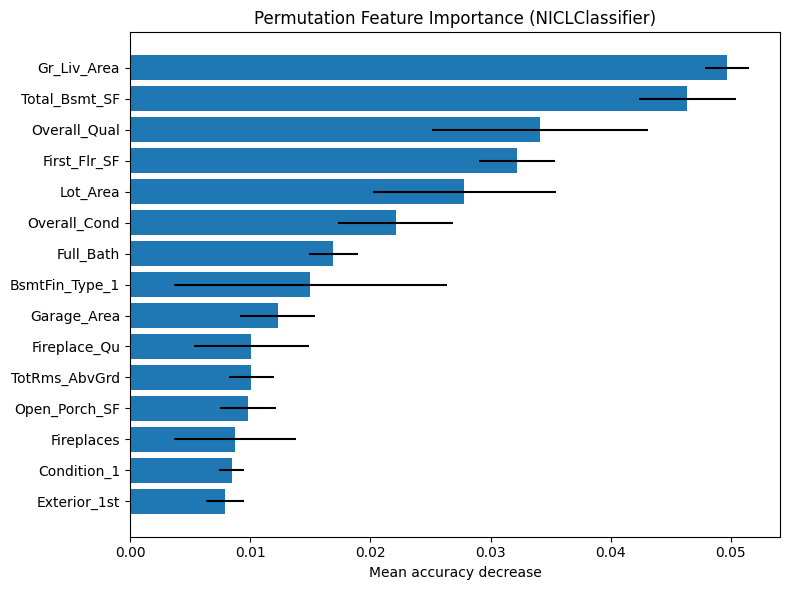

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

top_idx = sorted_idx[:top_n][::-1]
ax.barh(
    range(top_n),
    perm_result.importances_mean[top_idx],
    xerr=perm_result.importances_std[top_idx],
    align="center",
)
ax.set_yticks(range(top_n))
ax.set_yticklabels([X_test.columns[i] for i in top_idx])
ax.set_xlabel("Mean accuracy decrease")
ax.set_title("Permutation Feature Importance (NICLClassifier)")

plt.tight_layout()
plt.show()

---

## 6. SHAP (SHapley Additive exPlanations)

SHAP provides per-sample, per-feature explanations based on game-theoretic Shapley values. Unlike permutation importance which gives a global ranking, SHAP shows **why the model made a specific prediction** for each individual sample.

We use `KernelExplainer` since it works with any model — including the `NICLClassifier` pipeline.

In [18]:
import shap
import pandas as pd
from joblib import Parallel, delayed

# Explain a subset of test samples
X_explain = X_test.iloc[:50]
feature_names = X_explain.columns.tolist()

# Use numpy arrays for SHAP to avoid DataFrame/column mismatches
background = X_train.sample(50, random_state=42).values

# Wrap predict_proba, converting numpy arrays back to DataFrames for the pipeline
def predict_fn(X):
    return pipeline.predict_proba(pd.DataFrame(X, columns=feature_names))

# Parallelize by computing SHAP values one sample at a time across workers
def explain_sample(i):
    explainer = shap.KernelExplainer(predict_fn, background)
    return explainer.shap_values(X_explain.iloc[[i]].values)

results = Parallel(n_jobs=-1)(delayed(explain_sample)(i) for i in range(len(X_explain)))

# results is a list of per-sample SHAP values; stack them per class
n_classes = len(results[0])
shap_values = [np.concatenate([r[c] for r in results], axis=0) for c in range(n_classes)]


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


100%|██████████| 1/1 [01:30<00:00, 90.28s/it]


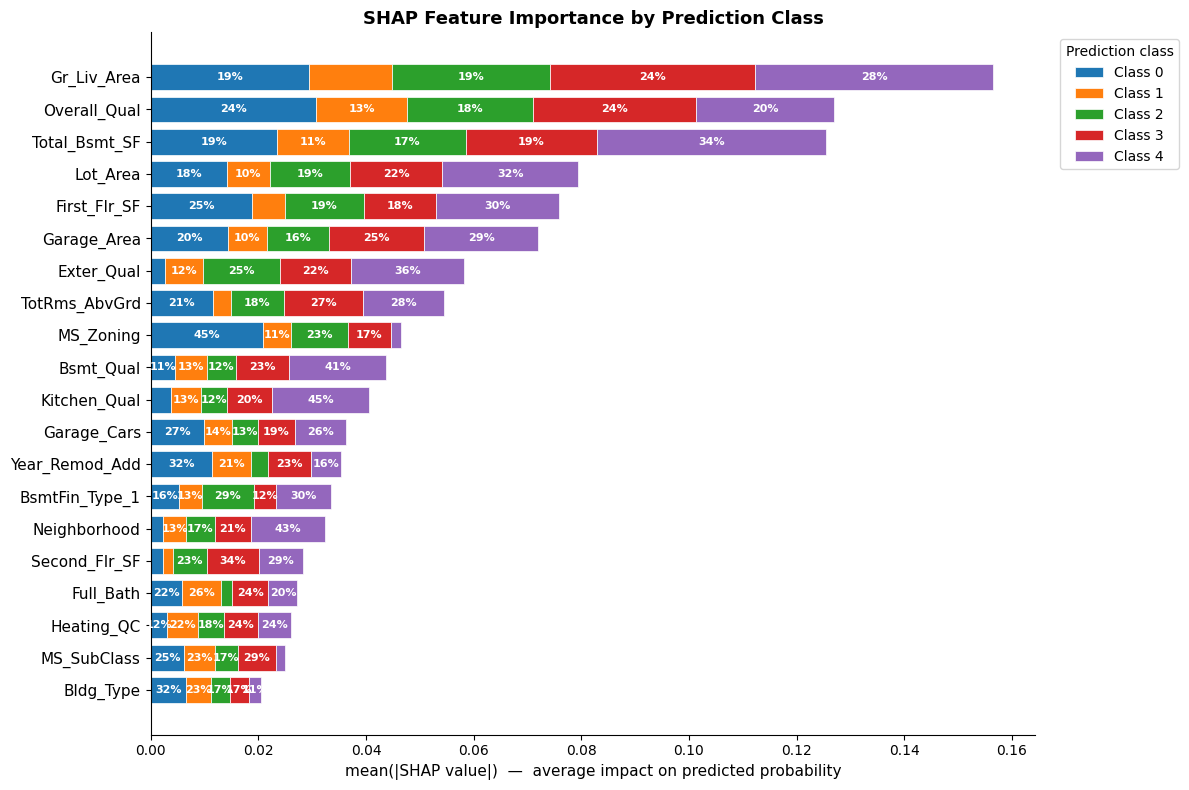

In [19]:
# Each result has shape (1, n_features, n_classes) — stack into (50, 80, 5)
shap_values_3d = np.concatenate(results, axis=0)

# Convert to list of (50, 80) arrays, one per class
shap_values = [shap_values_3d[:, :, c] for c in range(shap_values_3d.shape[2])]

# Class labels and percentages
classes = pipeline.classes_
pred_counts = np.array([(predictions == c).sum() for c in classes])
pred_pcts = pred_counts / len(predictions) * 100
class_names = [f"Class {c}" for c in classes]

# Compute per-class, per-feature mean |SHAP|
top_n = 20
mean_abs = np.array([np.abs(sv).mean(axis=0) for sv in shap_values])  # (n_classes, n_features)
global_importance = mean_abs.sum(axis=0)
sorted_idx = global_importance.argsort()[::-1][:top_n][::-1]

fig, ax = plt.subplots(figsize=(12, 8))

left = np.zeros(top_n)
colors = plt.cm.tab10.colors
for c_idx in range(len(classes)):
    widths = mean_abs[c_idx, sorted_idx]
    ax.barh(range(top_n), widths, left=left, label=class_names[c_idx],
            color=colors[c_idx], edgecolor="white", linewidth=0.5)
    # Add percentage label on each segment if wide enough
    for j in range(top_n):
        total = global_importance[sorted_idx[j]]
        pct = widths[j] / total * 100 if total > 0 else 0
        if pct >= 10:  # only label segments large enough to read
            ax.text(left[j] + widths[j] / 2, j, f"{pct:.0f}%",
                    ha="center", va="center", fontsize=8, color="white", fontweight="bold")
    left += widths

ax.set_yticks(range(top_n))
ax.set_yticklabels([feature_names[i] for i in sorted_idx], fontsize=11)
ax.set_xlabel("mean(|SHAP value|)  —  average impact on predicted probability", fontsize=11)
ax.set_title("SHAP Feature Importance by Prediction Class", fontsize=13, fontweight="bold")
ax.legend(title="Prediction class", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

---

## Summary

The `NICLClassifier` supports several explainability techniques out of the box thanks to its scikit-learn compatibility:

- **Prediction probabilities** (`predict_proba`) - understand model confidence per sample
- **Confidence analysis** - identify uncertain predictions for human review
- **Permutation importance** - measure feature contributions to model performance

Because `NICLClassifier` follows the scikit-learn API, any model-agnostic explainability tool (SHAP, LIME, partial dependence plots, etc.) can be applied directly.

For more details, see the [Neuralk documentation](https://docs.neuralk-ai.com/).